# EVA/PET Encapsulant Stack — Scenario Pipeline Demo

Demonstrates the **`Scenario`** class pipeline flow for module temperature and moisture ingress in an EVA/PET stack, and using `temp_mod` with constant humidity for acetic acid (HAc) generation in EVA.

**Scenario Pipeline:**

| Step | Function | Output | Depends on |
|------|----------|--------|------------|
| 1 | `spectral.poa_irradiance` | `poa` | — |
| 2 | `temperature.module` | `temp_mod` | `poa` |
| 3 | `rh_surface_job` | `rh_surface` | `temp_mod` |
| 4 | `front_encap_job` (EVA W001) | `rh_front_encap` | `temp_mod` |
| 5 | `back_encap_job` (EVA W001 + PET W017) | `rh_back_encap` | `temp_mod`, `rh_surface` |

## 1. Imports and data

In [6]:
import os
import json
import tempfile
import numpy as np
import pandas as pd
import pvdeg
import matplotlib.pyplot as plt

REPO_ROOT = os.path.dirname(os.path.dirname(pvdeg.__file__))
TUTORIALS_DATA = os.path.join(REPO_ROOT, "tutorials", "data")

# Redirect all Scenario job folders to the system temp directory.
# Keeps the repo working directory free of pvd_job_* clutter.
pvdeg.config.SCENARIO_OUTPUT_PATH = tempfile.gettempdir()

In [7]:
LOCATIONS = {
    "Golden, CO": ("psm4_golden.csv", "meta_golden.json"),
    "Miami, FL": ("psm4_miami.csv", "meta_miami.json"),
    "New York, NY": ("psm4_nyc.csv", "meta_nyc.json"),
}

all_weather, all_meta = {}, {}
for loc, (wf, mf) in LOCATIONS.items():
    df = pd.read_csv(
        os.path.join(TUTORIALS_DATA, wf),
        index_col=0,
        parse_dates=True,
    )
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    with open(os.path.join(TUTORIALS_DATA, mf)) as _f:
        mt = json.load(_f)
    all_weather[loc], all_meta[loc] = df, mt
    print(f"  {loc}: {len(df)} rows  ({mt['latitude']:.2f}°N, {mt['longitude']:.2f}°E)")
# Single-location aliases used by the demonstration cells below
weather_df = all_weather["Golden, CO"]
meta = all_meta["Golden, CO"]

  Golden, CO: 8760 rows  (39.73°N, -105.18°E)
  Miami, FL: 8760 rows  (25.77°N, -80.18°E)
  New York, NY: 8760 rows  (40.65°N, -73.98°E)


## 2. Job parameter setup

PVDeg functions are added to the pipeline via `addJob()`. For humidity functions that expect
`rh_ambient` and `temp_ambient`, we pass those as explicit kwargs from the weather data once,
then use `depends_on` only for upstream pipeline outputs (`temp_mod`, `rh_surface`).

In [ ]:
# Shared kwargs for humidity jobs
HUMIDITY_BASE_KWARGS = {
    "rh_ambient": weather_df["relative_humidity"],
    "temp_ambient": weather_df["temp_air"],
}

FRONT_ENCAP_KWARGS = {
    **HUMIDITY_BASE_KWARGS,
    # encapsulant="W001" is default for front_encapsulant
}

BACK_ENCAP_KWARGS = {
    "backsheet": "W017",  # PET (Kempe, unpublished)
    "encapsulant": "W001",  # EVA (Kempe 2006)
    "backsheet_thickness": 0.3,  # mm — typical PET backsheet
    "back_encap_thickness": 0.46,  # mm — typical EVA encapsulant
    "output": "rh",
}

## 3. Scenario: addModule and addJob

`addModule` registers the module-level configuration (temperature model, racking)
and named material layers. Here we load two materials from the `H2Opermeation` database:

- **`encapsulant`**: EVA W001 (Kempe 2006) — front and back encapsulant
- **`backsheet`**: PET W017 (Kempe, unpublished) — backsheet moisture barrier

In [16]:
s = pvdeg.Scenario(
    name="eva-pet-module-stack",
    weather_data=weather_df,
    meta_data=meta,
)

# Register the module with temperature model settings and material layers
s.addModule(
    module_name="glass-eva-pet",
    racking="open_rack_glass_polymer",
    temperature_model="sapm",
    materials={
        "encapsulant": {
            "material_file": "H2Opermeation",
            "material_name": "W001",  # EVA (Kempe 2006)
        },
        "backsheet": {
            "material_file": "H2Opermeation",
            "material_name": "W017",  # PET (Kempe, unpublished)
        },
    },
)

# Job 1 — POA irradiance
s.addJob(func=pvdeg.spectral.poa_irradiance, name="poa")

# Job 2 — module temperature
s.addJob(
    func=pvdeg.temperature.module,
    name="temp_mod",
    depends_on={"poa": "poa"},
)

# Job 3 — surface RH (ambient RH mapped to module temperature)
s.addJob(
    func=(pvdeg.humidity.surface_relative, HUMIDITY_BASE_KWARGS),
    name="rh_surface",
    depends_on={"temp_module": "temp_mod"},
)

# Job 4 — front encapsulant RH (EVA W001, glass side)
s.addJob(
    func=(pvdeg.humidity.front_encapsulant, FRONT_ENCAP_KWARGS),
    name="rh_front_encap",
    depends_on={"temp_module": "temp_mod"},
)

# Job 5 — back encapsulant RH (PET W017 -> EVA W001, backsheet side)
s.addJob(
    func=(pvdeg.humidity.back_encapsulant_water_concentration, BACK_ENCAP_KWARGS),
    name="rh_back_encap",
    depends_on={"temp_module": "temp_mod", "rh_surface": "rh_surface"},
)

print("Module layers:", list(s.modules[0]["material_params"].keys()))

Module layers: ['encapsulant', 'backsheet']


In [10]:
# Show the material parameters loaded from H2Opermeation for each layer
if "s" in globals():
    mat = s.modules[0]["material_params"]
elif "all_scenarios" in globals() and len(all_scenarios) > 0:
    sample_location = next(iter(all_scenarios.keys()))
    mat = all_scenarios[sample_location].modules[0]["material_params"]
else:
    raise RuntimeError("Run the Scenario setup cell first.")

for layer, params in mat.items():
    name = params.get("name", "?")
    alias = params.get("alias", "?")
    print(f"\n{layer.upper()} — {alias} ({name})")
    skip = {"name", "alias", "contributor", "source", "Fickian"}
    for k, v in params.items():
        if k not in skip:
            val = v["value"] if isinstance(v, dict) else v
            units = v.get("units", "") if isinstance(v, dict) else ""
            print(f"  {k:6s} = {val}  [{units}]")


ENCAPSULANT — EVA (Ethylene Vinyl Acetate)
  Ead    = 38.139966396438  []
  Do     = 2.31097881676966  []
  Eas    = 16.7286220351073  []
  So     = 1.81390701967487  []
  Eap    = 55.1578532714609  []
  Po     = 40728267519.3687  []

BACKSHEET — PET-2 (Polyethylene Terepthalate, ST504)
  Ead    = 49.1988088587438  []
  Do     = 1.43136116146877  []
  Eas    = 6.20764844309352  []
  So     = 0.106698381856152  []
  Eap    = 55.4064573018373  []
  Po     = 1319534666.90318  []


## 4. Run the pipeline

In [17]:
all_scenarios = {}
all_results = {}
module_name = "glass-eva-pet"

for loc in LOCATIONS:
    weather_loc = all_weather[loc]
    humidity_base_kwargs_loc = {
        "rh_ambient": weather_loc["relative_humidity"],
        "temp_ambient": weather_loc["temp_air"],
    }

    front_encap_kwargs_loc = {
        **humidity_base_kwargs_loc,
    }

    back_encap_kwargs_loc = {
        "backsheet": "W017",  # PET (Kempe, unpublished)
        "encapsulant": "W001",  # EVA (Kempe 2006)
        "backsheet_thickness": 0.3,  # mm — typical PET backsheet
        "back_encap_thickness": 0.46,  # mm — typical EVA encapsulant
        "output": "rh",
    }

    s_loc = pvdeg.Scenario(
        name=f"eva-pet-module-stack-{loc.replace(', ', '-').replace(' ', '_')}",
        weather_data=weather_loc,
        meta_data=all_meta[loc],
    )

    # Register the module with temperature model settings and material layers
    s_loc.addModule(
        module_name=module_name,
        racking="open_rack_glass_polymer",
        temperature_model="sapm",
        materials={
            "encapsulant": {
                "material_file": "H2Opermeation",
                "material_name": "W001",  # EVA (Kempe 2006)
            },
            "backsheet": {
                "material_file": "H2Opermeation",
                "material_name": "W017",  # PET (Kempe, unpublished)
            },
        },
    )

    # Job 1 — POA irradiance
    s_loc.addJob(func=pvdeg.spectral.poa_irradiance, name="poa")

    # Job 2 — module temperature
    s_loc.addJob(
        func=pvdeg.temperature.module,
        name="temp_mod",
        depends_on={"poa": "poa"},
    )

    # Job 3 — surface RH (ambient RH mapped to module temperature)
    s_loc.addJob(
        func=(pvdeg.humidity.surface_relative, humidity_base_kwargs_loc),
        name="rh_surface",
        depends_on={"temp_module": "temp_mod"},
    )

    # Job 4 — front encapsulant RH (EVA W001, glass side)
    s_loc.addJob(
        func=(pvdeg.humidity.front_encapsulant, front_encap_kwargs_loc),
        name="rh_front_encap",
        depends_on={"temp_module": "temp_mod"},
    )

    # Job 5 — back encapsulant RH (PET W017 -> EVA W001, backsheet side)
    s_loc.addJob(
        func=(
            pvdeg.humidity.back_encapsulant_water_concentration,
            back_encap_kwargs_loc,
        ),
        name="rh_back_encap",
        depends_on={"temp_module": "temp_mod", "rh_surface": "rh_surface"},
    )

    s_loc.run()

    res_loc = s_loc.results[module_name]
    all_scenarios[loc] = s_loc
    all_results[loc] = res_loc

print("Pipeline complete for:", list(all_results.keys()))

The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
Pipeline complete for: ['Golden, CO', 'Miami, FL', 'New York, NY']


## 5. Moisture transport results

Pipeline results for all three locations overlaid on a single figure:

| Panel | Quantity | Physical meaning |
|-------|----------|------------------|
| 1 | Module temperature [°C] | Thermal driver for degradation mechanisms |
| 2 | Surface RH & front encapsulant RH [%] | Moisture at the glass/EVA interface |
| 3 | Back encapsulant RH [%] | Moisture arriving through the PET backsheet |

The front encapsulant RH is lower than the surface RH because EVA moisture
solubility is temperature dependent. The back encapsulant RH is lower still
because the PET backsheet acts as a moisture barrier.


Text(0.5, 1.01, 'Multi-layer stack — moisture transport by location (2020)')

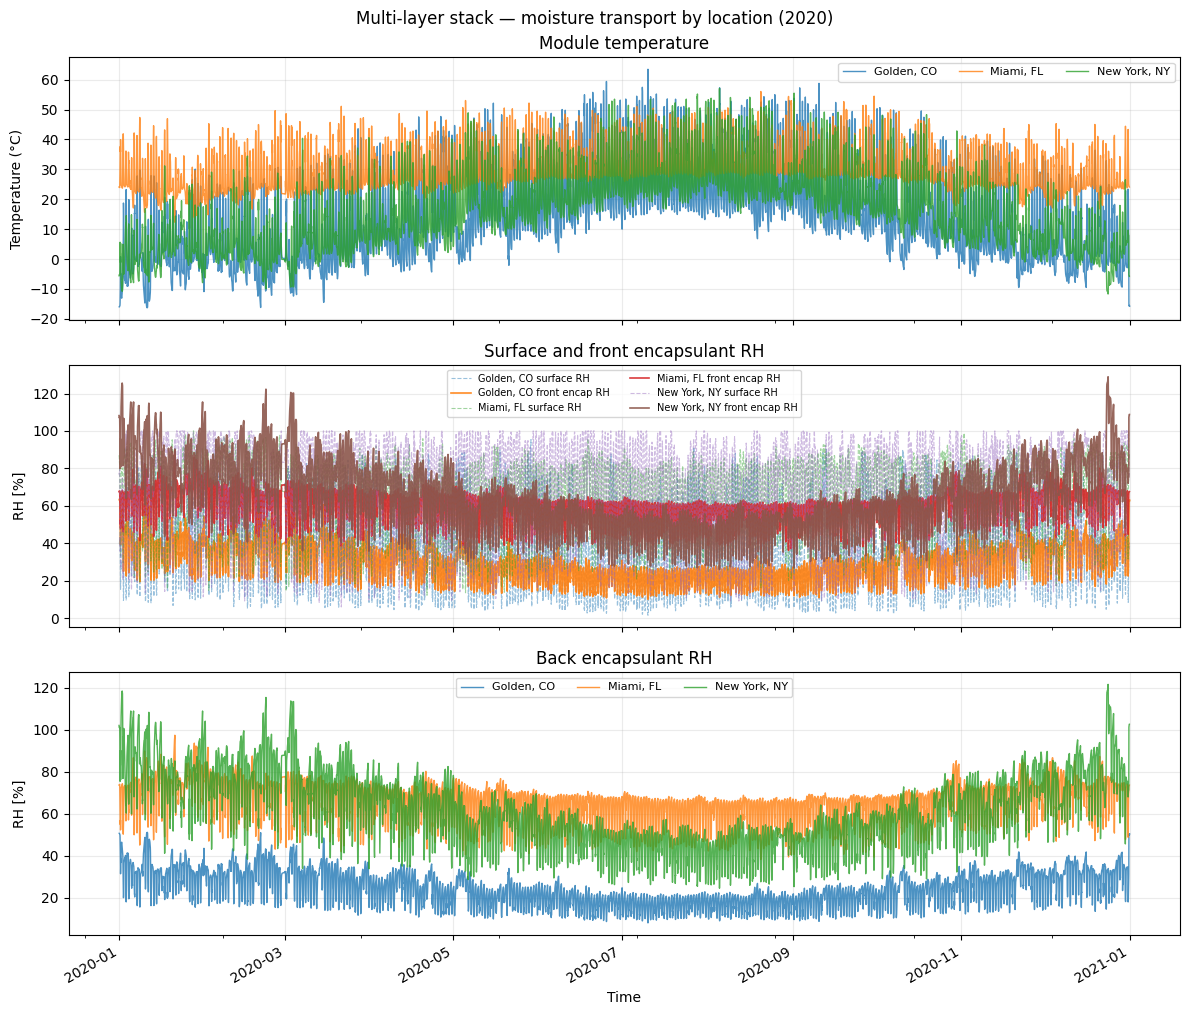

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for loc, res_loc in all_results.items():
    res_loc["temp_mod"].plot(ax=axes[0], linewidth=1.0, alpha=0.8, label=loc)
    res_loc["rh_surface"].plot(
        ax=axes[1], linewidth=0.8, alpha=0.45, linestyle="--", label=f"{loc} surface RH"
    )
    res_loc["rh_front_encap"].plot(
        ax=axes[1], linewidth=1.2, alpha=0.9, label=f"{loc} front encap RH"
    )
    res_loc["rh_back_encap"].plot(ax=axes[2], linewidth=1.0, alpha=0.8, label=loc)

axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Module temperature")
axes[1].set_ylabel("RH [%]")
axes[1].set_title("Surface and front encapsulant RH")
axes[2].set_ylabel("RH [%]")
axes[2].set_title("Back encapsulant RH")
axes[2].set_xlabel("Time")

axes[0].legend(ncol=3, fontsize=8)
axes[1].legend(ncol=2, fontsize=7)
axes[2].legend(ncol=3, fontsize=8)

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.suptitle(
    "Multi-layer stack — moisture transport by location (2020)",
    y=1.01,
    fontsize=12,
)

## 6. Acetic acid generation in EVA

Acetic acid (HAc) is produced by hydrolysis of the vinyl acetate groups in EVA, a reaction that requires both heat and moisture. Its accumulation in the encapsulant is a known precursor to corrosion of cell metallization and glass/EVA interface degradation.

In the current literature, only temperature-induced acetic acid generation data at constant (85%) relative humidity are available. Although the encapsulant RH values computed in Steps 3–5 (`rh_surface`, `rh_front_encap`, `rh_back_encap`) characterise the moisture environment through the stack, they are not used in the HAc calculations here. However, once a validated humidity-coupled HAc model is published, a new job can be implemented in PVDeg and the Scenario pipeline could easily integrate these outputs into the HAc calculation via the `depends_on` argument.

Using `temp_mod` from the Scenario pipeline, two post-processing functions estimate the HAc chemistry directly in the EVA layer:

- `acetic_acid_generation`: instantaneous HAc generation rate [ng/min/g] — nanograms of acetic acid produced per minute per gram of EVA
- `acetic_acid_cumulative`: cumulative HAc concentration [mg/g] integrated over the full year

In [13]:
# Summary metrics for all locations
print(
    f"{'Location':<18}  {'Rate start':>16}  {'Cumul. 1000 h':>16}  {'Cumul. 3000 h':>16}"
)
print(f"{'':18}  {'[ng/min/g]':>16}  {'[mg/g]':>16}  {'[mg/g]':>16}")
print("-" * 72)
for loc, res_loc in all_results.items():
    temp_loc = res_loc["temp_mod"]
    hac_rate_loc = pvdeg.degradation.acetic_acid_generation(
        temp_module=temp_loc, encapsulant="AA002"
    )
    hac_cum_loc = pvdeg.degradation.acetic_acid_cumulative(
        temp_module=temp_loc, encapsulant="AA002"
    )
    print(
        f"{loc:<18}  {float(hac_rate_loc.iloc[0]):>16.6f}"
        f"  {float(hac_cum_loc.iloc[999]):>16.6f}"
        f"  {float(hac_cum_loc.iloc[2999]):>16.6f}"
    )

Location                  Rate start     Cumul. 1000 h     Cumul. 3000 h
                          [ng/min/g]            [mg/g]            [mg/g]
------------------------------------------------------------------------
Golden, CO                  0.000008          0.000020          0.000180
Miami, FL                   0.002328          0.000233          0.000925
New York, NY                0.000041          0.000017          0.000127


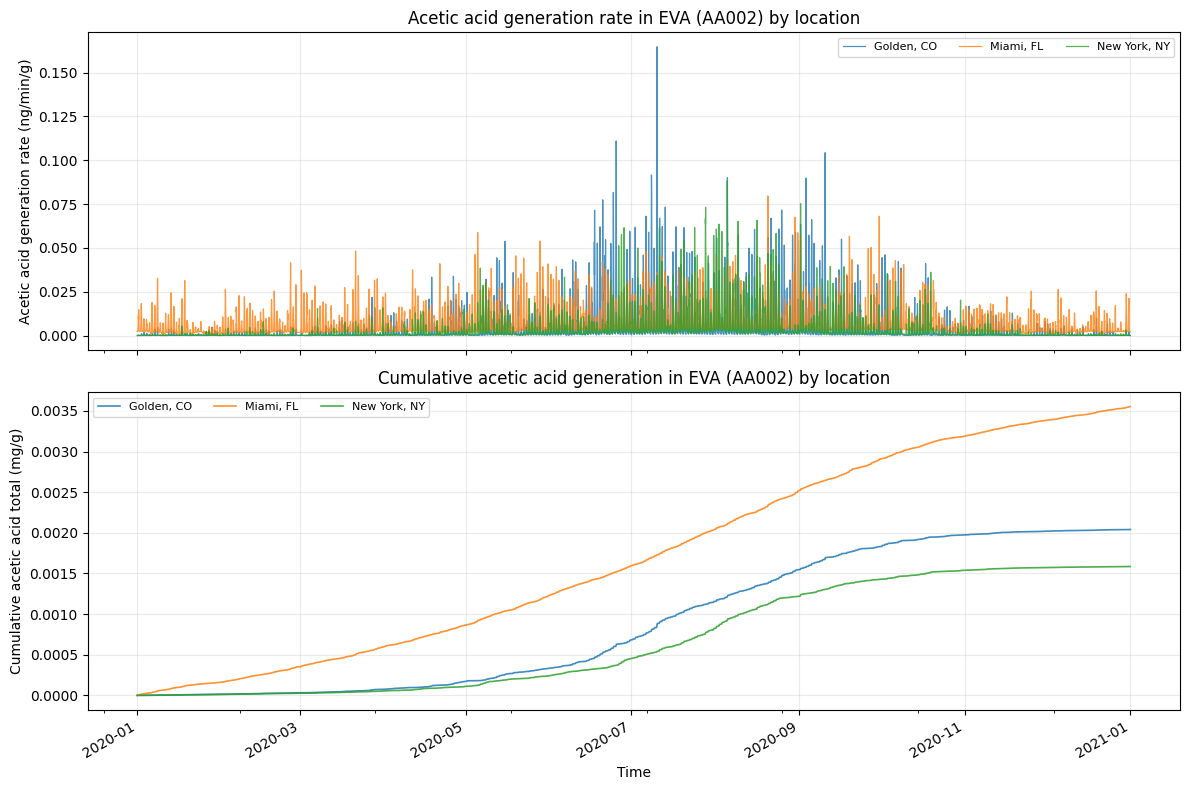

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for loc, res_loc in all_results.items():
    temp_loc = res_loc["temp_mod"]

    hac_rate_loc = pvdeg.degradation.acetic_acid_generation(
        temp_module=temp_loc, encapsulant="AA002"
    )
    hac_cum_loc = pvdeg.degradation.acetic_acid_cumulative(
        temp_module=temp_loc, encapsulant="AA002"
    )

    hac_rate_loc.plot(ax=axes[0], linewidth=0.9, alpha=0.8, label=loc)
    hac_cum_loc.plot(ax=axes[1], linewidth=1.2, alpha=0.85, label=loc)

axes[0].set_ylabel(
    "Acetic acid generation rate (ng/min/g)"
)  # nanograms of acetic acid produced per minute per gram of EVA
axes[0].set_title("Acetic acid generation rate in EVA (AA002) by location")
axes[1].set_ylabel("Cumulative acetic acid total (mg/g)")
axes[1].set_title("Cumulative acetic acid generation in EVA (AA002) by location")
axes[1].set_xlabel("Time")

axes[0].legend(ncol=3, fontsize=8)
axes[1].legend(ncol=3, fontsize=8)

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()

---
## Summary and next steps

This notebook demonstrates the **`Scenario` pipeline architecture** for encapsulant
degradation chemistry in a glass/EVA/PET module stack. The key features
demonstrated are `addModule()` (racking, temperature modeling, and named material
layers), sequential job chaining via `depends_on`, permeation database lookup, and
multi-location execution across three climate zones.

The pipeline produces a connected physical story:
- **Steps 1–2** establish the module's thermal environment (`poa` → `temp_mod`)
- **Steps 3–5** propagate moisture through the stack: ambient air → module surface → front EVA → PET backsheet → back EVA
- **Section 6** uses `temp_mod` directly to estimate acetic acid build-up in EVA (Arrhenius kinetics, AA002 database entry)

The moisture and HAc outputs represent **encapsulant stressors** at different layers.
Combining them into a module-level degradation metric (e.g. optical coupling loss
from delamination, or corrosion rate from HAc at metallization) requires additional
models not yet implemented in pvdeg. When available, they can be chained directly
via `depends_on`.